In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 109k/109k [00:00<00:00, 47.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/taeefnajib/used-car-price-prediction-dataset/versions/1


In [2]:
import pandas as pd
import os
os.listdir(path)

['used_cars.csv']

In [8]:
import os
df=pd.read_csv(os.path.join(path,'used_cars.csv'))
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [9]:
df.shape

(4009, 12)

In [10]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [14]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [12]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [16]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [18]:
(df.isnull().sum()/len(df))*100

,0
brand,0.000000
model,0.000000
model_year,0.000000
milage,0.000000
fuel_type,4.240459
engine,0.000000
transmission,0.000000
ext_col,0.000000
int_col,0.000000
accident,2.818658


In [21]:
df.duplicated().sum()

np.int64(0)

In [20]:
numerical= df.select_dtypes(include=['int64','float64'])
categorical=df.select_dtypes(include=['object'])
print(numerical.columns)
print(categorical.columns)

Index(['model_year'], dtype='object')
Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='object')


In [22]:
for col in categorical.columns:
  print(col)
  print(df[col].value_counts())
  print()

brand
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
L

In [29]:
df.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [28]:
df["fuel_type"].fillna(df['fuel_type'].mode()[0],inplace=True)
df['accident'].fillna(df['accident'].mode()[0],inplace=True)
df['clean_title'].fillna(df['clean_title'].mode()[0],inplace=True)

/tmp/ipykernel_1877/3047514887.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['accident'].fillna(df['accident'].mode()[0],inplace=True)
/tmp/ipykernel_1877/3047514887.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

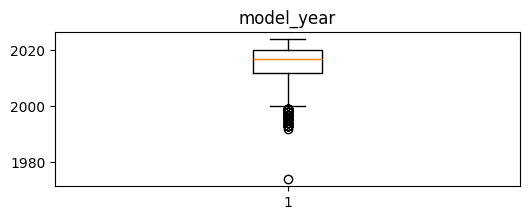

In [45]:
import matplotlib.pyplot as plt
for col in numerical.columns:
  plt.figure(figsize=(6,2))
  plt.boxplot(df[col].dropna())
  plt.title(col)
  plt.show()

In [30]:
df.drop_duplicates(inplace=True)

In [34]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [33]:
df["price"]=(df['price'].str.replace('$','',regex=False).str.replace(",","",regex=False).astype(float))

In [41]:
df['milage']=df['milage'].str.replace('mi.','',regex=False).str.replace(',','',regex=False).astype(int)

In [60]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Car_Age
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Yes,54598.0,4
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999.0,5


In [61]:
for col in numerical.columns:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  df=df[(df[col]>=lower) & (df[col]<=upper)]

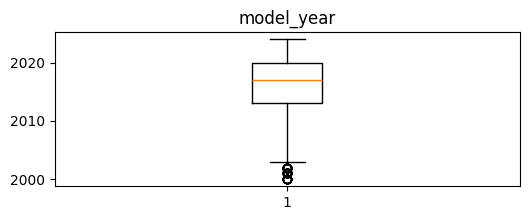

In [55]:
import matplotlib.pyplot as plt
for col in numerical.columns:
  plt.figure(figsize=(6,2))
  plt.boxplot(df[col].dropna())
  plt.title(col)
  plt.show()

In [59]:
df["Car_Age"] = 2026 - df["model_year"]

/tmp/ipykernel_1877/3150100095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Car_Age"] = 2026 - df["model_year"]


In [62]:
df["Price_per_KM"]=df['price']/(df['milage']+1)

/tmp/ipykernel_1877/2427983799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Price_per_KM"]=df['price']/(df['milage']+1)


In [64]:
df["Milage_per_Year"]=(df['milage']/(df['Car_Age']+1))

/tmp/ipykernel_1877/428713613.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Milage_per_Year"]=(df['milage']/(df['Car_Age']+1))


In [65]:
df.to_csv("cleaned_used_cars.csv",index=False)